# ScoutRadar Phase 2 Dashboard

This notebook is the report-facing EDA and model-comparison dashboard for the transfer-success classification pipeline. It is designed to run offline against the generated Phase 2 outputs.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os


sys.path.append(os.path.abspath('..'))

from src.data.transfer_dataset import build_transfer_modeling_dataset

sns.set_theme(style="whitegrid", context="talk")

dataset_path = Path("../data/processed/transfer_modeling_dataset.csv")
model_summary_path = Path("../models/generated/phase2_model_comparison.csv")

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
else:
    outputs = build_transfer_modeling_dataset(output_dir="../data/processed")
    df = outputs["modeling_dataset"].copy()

df["transfer_date"] = pd.to_datetime(df["transfer_date"], errors="coerce")
df.head()

,transfer_key,player_id,player_full_name,transfer_date,transfer_season,source_club_id,source_club_name,source_competition_id,source_competition_name,destination_club_id,...,player_window_start_180d,player_window_end_180d,player_window_start_365d,player_window_end_365d,source_api_cache_file,destination_api_cache_file,follow_up_window_end,target_end_market_value_date,target_is_eligible,target_failure_reason
0,7825_2018-07-01_6195_5,7825,Pepe Reina,2018-07-01,18/19,6195,SSC Napoli,IT1,serie-a,5,...,2018-01-02,2018-06-30,2017-07-01,2018-06-30,NaN,NaN,2020-07-01,2020-04-08,True,NaN
1,22141_2018-07-01_1025_12,22141,Antonio Mirante,2018-07-01,18/19,1025,Bologna,IT1,serie-a,12,...,2018-01-02,2018-06-30,2017-07-01,2018-06-30,NaN,NaN,2020-07-01,2020-04-08,True,NaN
2,27490_2018-07-01_1147_826,27490,Jean-Louis Leca,2018-07-01,18/19,1147,AC Ajaccio,FR1,ligue-1,826,...,2018-01-02,2018-06-30,2017-07-01,2018-06-30,NaN,NaN,2020-07-01,2020-04-08,True,NaN
3,28140_2018-07-01_989_415,28140,Max Gradel,2018-07-01,18/19,989,Bournemouth,GB1,premier-league,415,...,2018-01-02,2018-06-30,2017-07-01,2018-06-30,NaN,NaN,2020-07-01,2020-04-08,True,NaN
4,29692_2018-07-01_2288_379,29692,Lukasz Fabianski,2018-07-01,18/19,2288,Swansea,GB1,premier-league,379,...,2018-01-02,2018-06-30,2017-07-01,2018-06-30,NaN,NaN,2020-07-01,2020-04-08,True,NaN


In [7]:
summary = pd.DataFrame(
    [
        {
            "rows": len(df),
            "positive_rate": round(df["transfer_success"].mean(), 4),
            "start_date": df["transfer_date"].min(),
            "end_date": df["transfer_date"].max(),
            "unique_players": df["player_id"].nunique(),
            "destination_leagues": df["destination_competition_id"].nunique(),
        }
    ]
)
summary

,rows,positive_rate,start_date,end_date,unique_players,destination_leagues
0,5383,0.201,2018-07-01,2022-06-30,2467,5


/tmp/ipykernel_101600/4281217440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="transfer_success", ax=axes[0], palette="crest")
/tmp/ipykernel_101600/4281217440.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=position_success, x="position", y="transfer_success", ax=axes[1], palette="mako")
/tmp/ipykernel_101600/4281217440.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="transfer_success", y="pre_transfer_market_value", ax=axes[2], palette="flare")
/tmp/ipykernel_101600/4281217440.py:20: FutureWarn

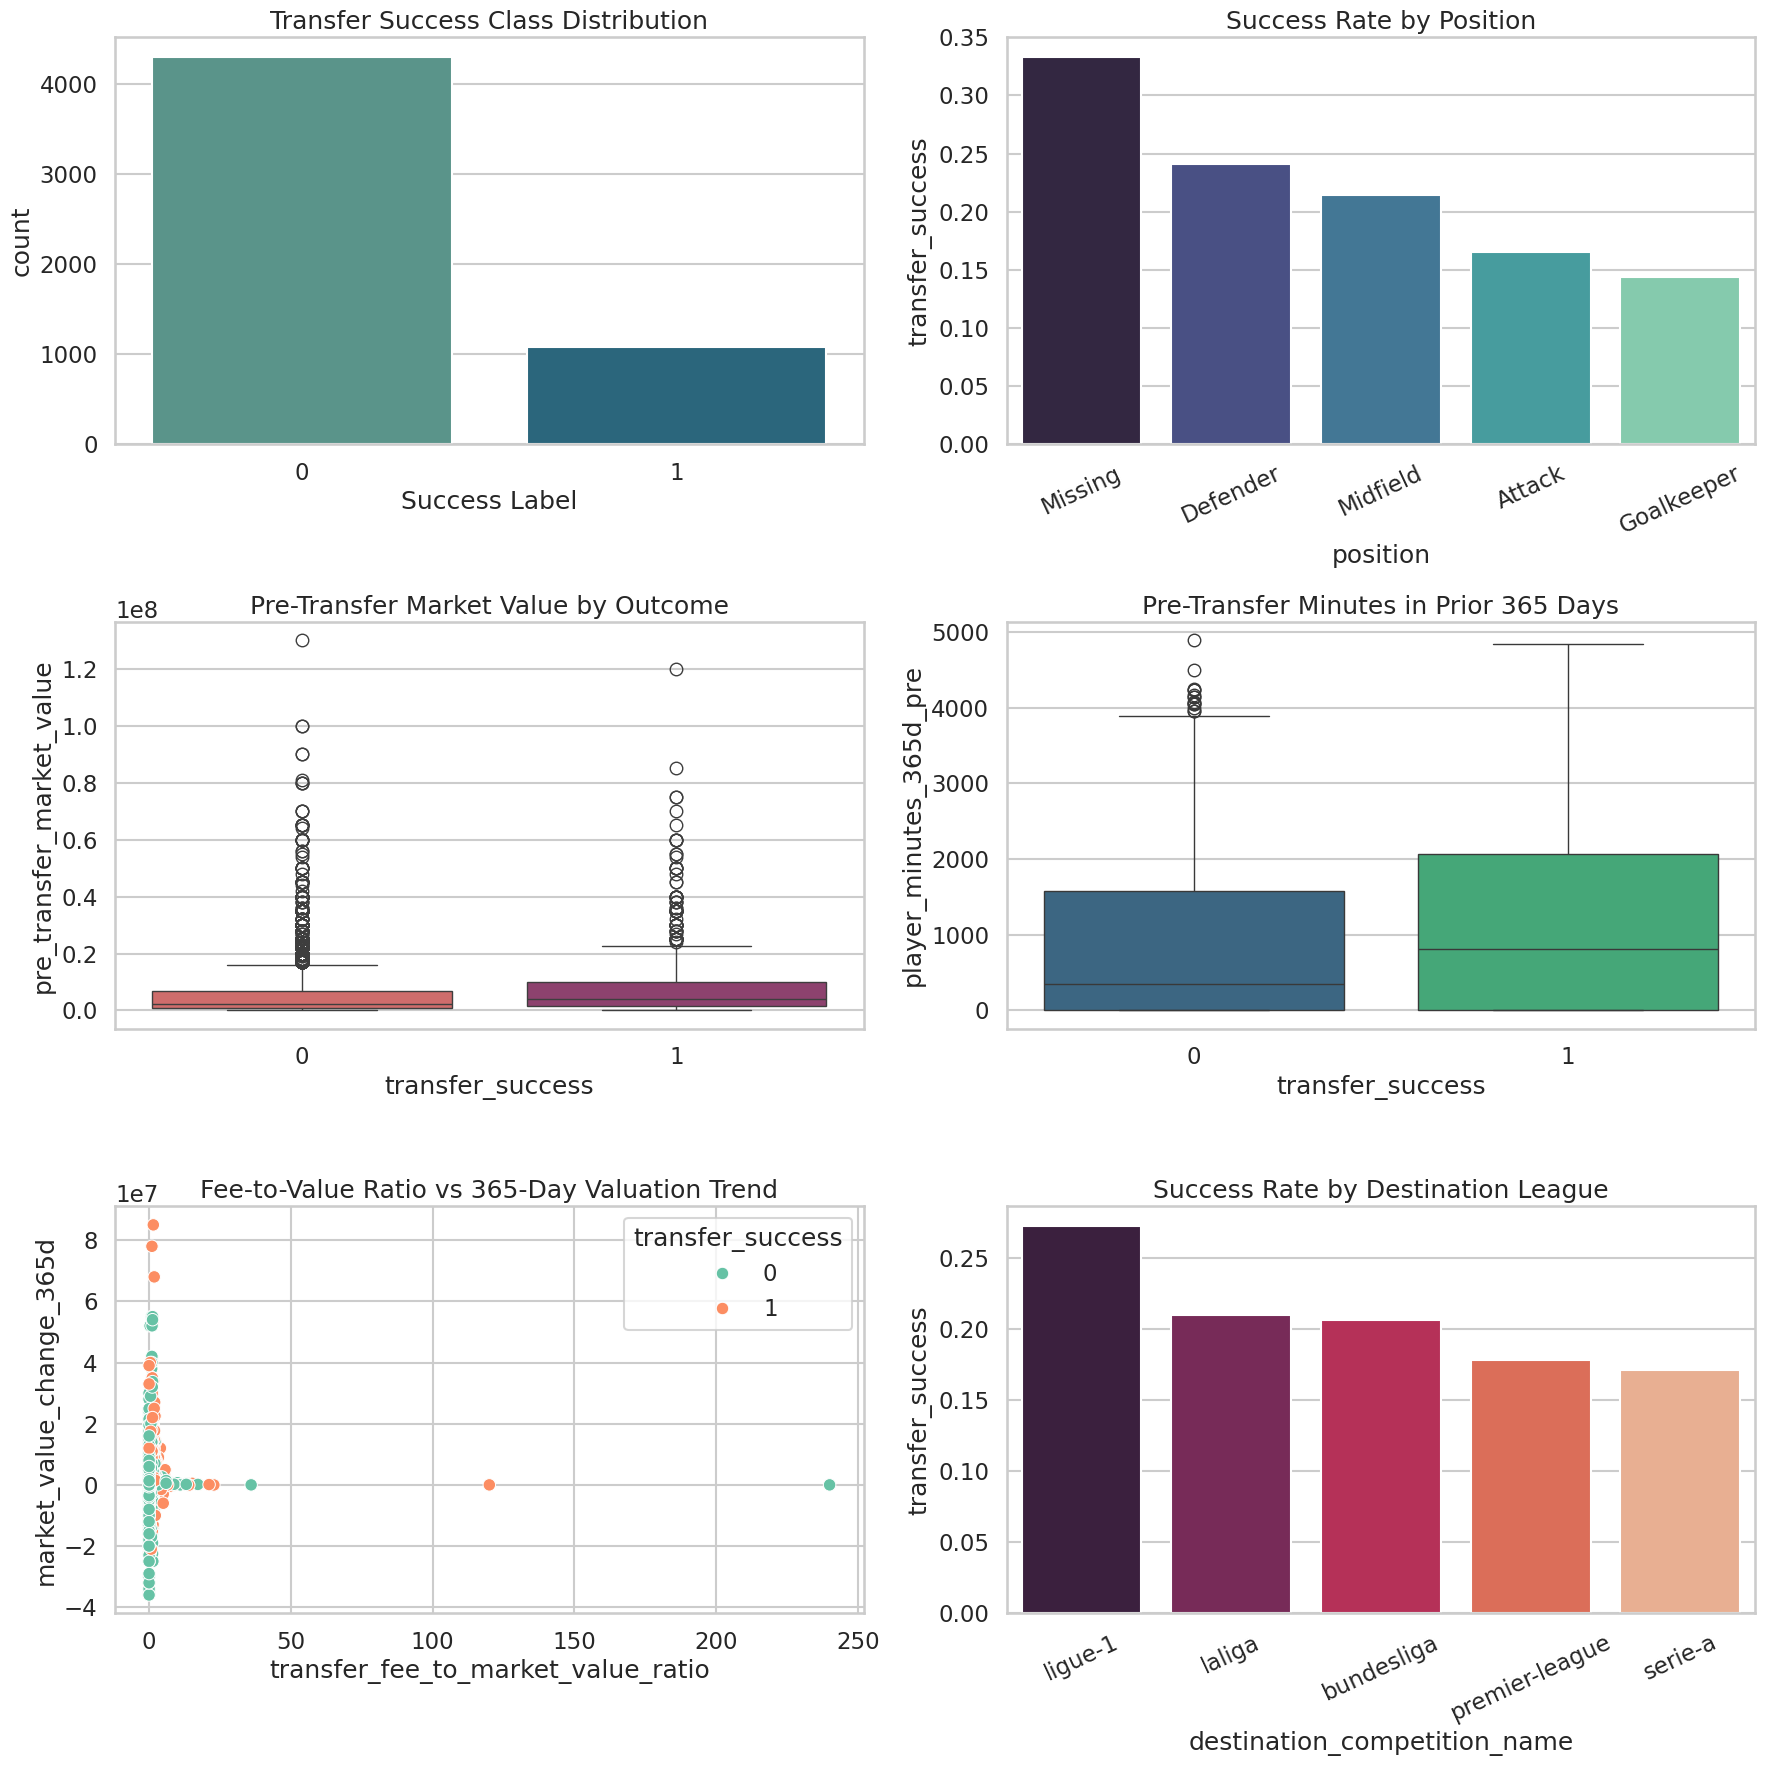

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

sns.countplot(data=df, x="transfer_success", ax=axes[0], palette="crest")
axes[0].set_title("Transfer Success Class Distribution")
axes[0].set_xlabel("Success Label")

position_success = (
    df.groupby("position", as_index=False)["transfer_success"]
    .mean()
    .sort_values("transfer_success", ascending=False)
)
sns.barplot(data=position_success, x="position", y="transfer_success", ax=axes[1], palette="mako")
axes[1].set_title("Success Rate by Position")
axes[1].tick_params(axis="x", rotation=25)

sns.boxplot(data=df, x="transfer_success", y="pre_transfer_market_value", ax=axes[2], palette="flare")
axes[2].set_title("Pre-Transfer Market Value by Outcome")

sns.boxplot(data=df, x="transfer_success", y="player_minutes_365d_pre", ax=axes[3], palette="viridis")
axes[3].set_title("Pre-Transfer Minutes in Prior 365 Days")

sns.scatterplot(
    data=df,
    x="transfer_fee_to_market_value_ratio",
    y="market_value_change_365d",
    hue="transfer_success",
    ax=axes[4],
    palette="Set2",
)
axes[4].set_title("Fee-to-Value Ratio vs 365-Day Valuation Trend")

league_success = (
    df.groupby("destination_competition_name", as_index=False)["transfer_success"]
    .mean()
    .sort_values("transfer_success", ascending=False)
)
sns.barplot(data=league_success, x="destination_competition_name", y="transfer_success", ax=axes[5], palette="rocket")
axes[5].set_title("Success Rate by Destination League")
axes[5].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [10]:
if model_summary_path.exists():
    model_summary = pd.read_csv(model_summary_path)
    display(model_summary[["model_name", "val_f1", "test_f1", "test_accuracy", "test_missed_success_rate", "test_top20_precision"]])
else:
    print("Run `make train-phase2` first to populate the model comparison table.")

,model_name,val_f1,test_f1,test_accuracy,test_missed_success_rate,test_top20_precision
0,GradientBoostingClassifier,0.582716,0.426230,0.870050,0.585106,0.360248
1,SVC,0.471976,0.376963,0.852723,0.617021,0.279503
2,RandomForestClassifier,0.429487,0.285714,0.882426,0.797872,0.279503
3,LogisticRegression,0.411168,0.340909,0.784653,0.521277,0.273292
4,DummyClassifier,0.000000,0.000000,0.883663,1.000000,0.180124


## Business Interpretation Prompts

- Which positions or destination leagues are most associated with successful transfers?
- Does recent playing time before the move separate successful and unsuccessful transfers?
- Which model best balances overall technical performance with a low missed-success rate for scouts?